# DSN Mart Sales Prediction Hackathon

This is a machine learning model that predicts the `total_sales` for a product at a specific store using product and store attributes.

**Workflow:** loading & validating data -> cleaning & imputing (leak-free) -> feature engineering ->
encoding categoricals -> comparing candidate models with cross-validation -> tuning the top
candidates -> refitting the best model on all available training data -> prediction on `test.csv`
-> writing `submission.csv`.


In [38]:
# 1. Importing required libraries
import os
import time
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, RandomizedSearchCV
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    warnings.warn("xgboost is not installed - XGBoost will be skipped.")

try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    warnings.warn("catboost is not installed - CatBoost will be skipped.")

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set(style="whitegrid")

## 2. Load & validate the data

Looks for the CSVs in a `dataset/` subfolder first, then in the current directory.
Every load is wrapped so a missing or corrupt file produces a clear error message
instead of a confusing traceback deep inside pandas.

In [39]:
def load_csv(filename, search_dirs=("dataset", ".")):
    """Load a CSV from the first matching directory, with a clear error on failure."""
    tried = []
    for d in search_dirs:
        path = os.path.join(d, filename)
        tried.append(path)
        if os.path.exists(path):
            try:
                return pd.read_csv(path)
            except Exception as exc:
                raise RuntimeError(f"Found '{path}' but could not read it: {exc}") from exc
    raise FileNotFoundError(f"Could not find '{filename}'. Looked in: {tried}")


try:
    train_df = load_csv("train.csv")
    test_df = load_csv("test.csv")
    sample_submission = load_csv("sample_submission.csv")
except (FileNotFoundError, RuntimeError) as exc:
    print(f"[FATAL] Data loading failed: {exc}")
    raise

EXPECTED_TRAIN_COLS = {
    "id", "product_code", "product_weight_kg", "fat_content", "shelf_visibility",
    "product_category", "product_price", "store_code", "store_age_years",
    "store_size", "store_location_tier", "store_format", "total_sales",
}
EXPECTED_TEST_COLS = EXPECTED_TRAIN_COLS - {"total_sales"}

missing_train_cols = EXPECTED_TRAIN_COLS - set(train_df.columns)
missing_test_cols = EXPECTED_TEST_COLS - set(test_df.columns)
if missing_train_cols:
    raise ValueError(f"train.csv is missing expected columns: {missing_train_cols}")
if missing_test_cols:
    raise ValueError(f"test.csv is missing expected columns: {missing_test_cols}")
if set(sample_submission.columns) != {"id", "total_sales"}:
    raise ValueError(f"Unexpected sample_submission columns: {list(sample_submission.columns)}")

print(f"train: {train_df.shape}, test: {test_df.shape}, sample_submission: {sample_submission.shape}")
train_df.head()

train: (6818, 13), test: (1705, 12), sample_submission: (1705, 2)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


## 3. Quick exploratory checks

In [40]:
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print()
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])
print()
print("Unique stores (train/test):", train_df["store_code"].nunique(), "/", test_df["store_code"].nunique())
print("Unique products (train/test):", train_df["product_code"].nunique(), "/", test_df["product_code"].nunique())
print("Stores shared between train & test:",
      len(set(train_df["store_code"]) & set(test_df["store_code"])), "/", test_df["store_code"].nunique())

product_weight_kg    1225
store_size           1919
dtype: int64

product_weight_kg    306
store_size           491
dtype: int64

Unique stores (train/test): 10 / 10
Unique products (train/test): 1555 / 1082
Stores shared between train & test: 10 / 10


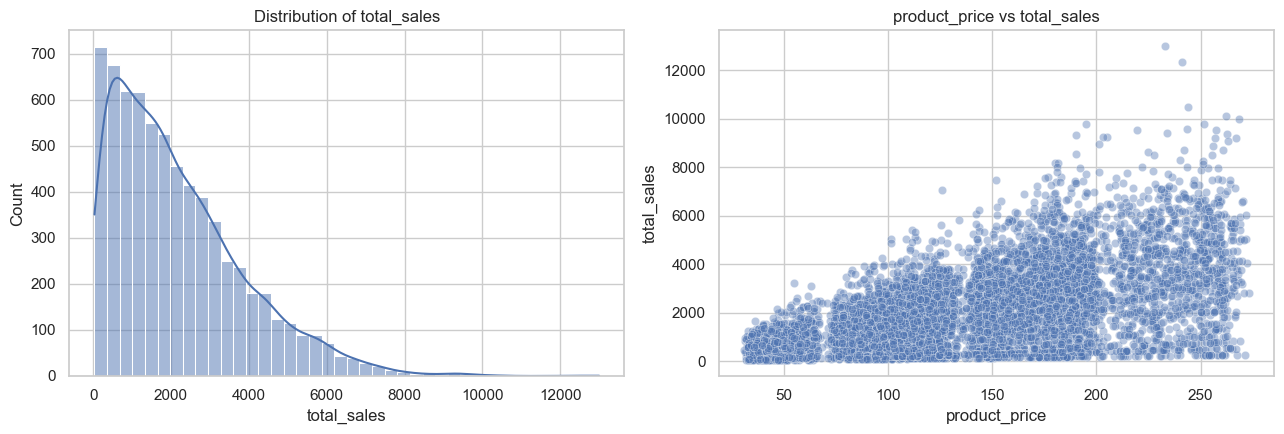

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(train_df["total_sales"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribution of total_sales")
sns.scatterplot(data=train_df, x="product_price", y="total_sales", alpha=0.4, ax=axes[1])
axes[1].set_title("product_price vs total_sales")
plt.tight_layout()
plt.show()

## 4. Cleaning

`product_category` has inconsistent capitalisation (`"Frozen Foods"` vs `"frozen foods"`),
per the dataset description. I normalised it. I also spot-check that `fat_content`,
`store_size`, `store_location_tier` and `store_format` only contain the values documented,
so a misspelling doesn't silently create an unecessary new category.

In [42]:
def normalize_category(df, col="product_category"):
    df = df.copy()
    df[col] = df[col].astype(str).str.strip().str.lower()
    return df

train_df = normalize_category(train_df)
test_df = normalize_category(test_df)

EXPECTED_VALUES = {
    "fat_content": {"Low Fat", "Regular"},
    "store_location_tier": {"Tier_1", "Tier_2", "Tier_3"},
    "store_format": {"Corner Shop", "Standard Supermarket", "Superstore", "Flagship Hypermarket"},
    "store_size": {"Small", "Medium", "Large"},
}
for col, expected in EXPECTED_VALUES.items():
    for name, df in [("train", train_df), ("test", test_df)]:
        observed = set(df[col].dropna().unique())
        unexpected = observed - expected
        if unexpected:
            warnings.warn(f"{name}.{col} has unexpected values: {unexpected}")

print("product_category values:", sorted(train_df["product_category"].unique()))

product_category values: ['baking goods', 'breads', 'breakfast', 'canned', 'dairy', 'frozen foods', 'fruits and vegetables', 'hard drinks', 'health and hygiene', 'household', 'meat', 'others', 'seafood', 'snack foods', 'soft drinks', 'starchy foods']


## 5. Missing-value imputation (leak-free)

`store_size` and `product_weight_kg` have missing values. Lookup tables are fit on
**train only**, then applied to both train and test, so nothing about the test set
influences the imputed values.

- `store_size`: mode by `store_code`, falling back to mode by `store_format`, falling
  back to the global mode (a few stores have `store_size` missing for every row).
- `product_weight_kg`: median by `product_code`, falling back to median by
  `product_category`, falling back to the global median.

In [43]:
def get_mode(series):
    modes = series.mode()
    return modes.iloc[0] if not modes.empty else np.nan


def fit_store_size_imputer(df):
    store_map = df.groupby("store_code")["store_size"].agg(get_mode)
    format_map = df.groupby("store_format")["store_size"].agg(get_mode)
    global_mode = get_mode(df["store_size"])
    return store_map, format_map, global_mode


def apply_store_size_imputer(df, store_map, format_map, global_mode):
    df = df.copy()
    df["store_size"] = df["store_size"].fillna(df["store_code"].map(store_map))
    df["store_size"] = df["store_size"].fillna(df["store_format"].map(format_map))
    df["store_size"] = df["store_size"].fillna(global_mode)
    return df


def fit_weight_imputer(df):
    product_map = df.groupby("product_code")["product_weight_kg"].median()
    category_map = df.groupby("product_category")["product_weight_kg"].median()
    global_median = df["product_weight_kg"].median()
    return product_map, category_map, global_median


def apply_weight_imputer(df, product_map, category_map, global_median):
    df = df.copy()
    df["product_weight_kg"] = df["product_weight_kg"].fillna(df["product_code"].map(product_map))
    df["product_weight_kg"] = df["product_weight_kg"].fillna(df["product_category"].map(category_map))
    df["product_weight_kg"] = df["product_weight_kg"].fillna(global_median)
    return df


store_size_map, format_size_map, global_size_mode = fit_store_size_imputer(train_df)
train_df = apply_store_size_imputer(train_df, store_size_map, format_size_map, global_size_mode)
test_df = apply_store_size_imputer(test_df, store_size_map, format_size_map, global_size_mode)

weight_product_map, weight_category_map, global_weight_median = fit_weight_imputer(train_df)
train_df = apply_weight_imputer(train_df, weight_product_map, weight_category_map, global_weight_median)
test_df = apply_weight_imputer(test_df, weight_product_map, weight_category_map, global_weight_median)

for name, df in [("train", train_df), ("test", test_df)]:
    for col in ["store_size", "product_weight_kg"]:
        remaining = df[col].isnull().sum()
        if remaining:
            raise ValueError(f"{name}.{col} still has {remaining} missing values after imputation")

print("Missing-value imputation complete - no NaNs remain in store_size / product_weight_kg.")

Missing-value imputation complete - no NaNs remain in store_size / product_weight_kg.


## 6. Outlier trimming (train only)

Rows more than 3 standard deviations from the mean `total_sales` are dropped from the
**training set only**, `test.csv` is never touched here, since I must produce a
prediction for every one of its rows regardless of how extreme it might look.

In [44]:
n_before = len(train_df)
mean_sales, std_sales = train_df["total_sales"].mean(), train_df["total_sales"].std()
lower, upper = mean_sales - 3 * std_sales, mean_sales + 3 * std_sales
train_df = train_df.loc[(train_df["total_sales"] >= lower) & (train_df["total_sales"] <= upper)].reset_index(drop=True)
print(f"Removed {n_before - len(train_df)} outlier rows out of {n_before} ({(n_before - len(train_df)) / n_before:.1%})")

Removed 68 outlier rows out of 6818 (1.0%)


## 7. Feature engineering

- `price_per_kg`: `product_price / product_weight_kg` captures value density that
  price or weight alone don't.
- `store_avg_sales`: a smoothed mean-target encoding of `store_code`. All 10 stores in
  `test.csv` also appear in `train.csv`, so this captures store-specific performance
  that isn't fully explained by `store_format` / `store_size` / `store_location_tier`
  alone. The encoding (and its smoothing) is fit on train only.

In [45]:
def add_price_per_kg(df, fill_value=None):
    df = df.copy()
    ratio = df["product_price"] / df["product_weight_kg"].replace(0, np.nan)
    if fill_value is None:
        fill_value = ratio.median()
    df["price_per_kg"] = ratio.fillna(fill_value)
    return df, fill_value


def fit_target_encoding(df, col, target="total_sales", smoothing=10):
    global_mean = df[target].mean()
    agg = df.groupby(col)[target].agg(["mean", "count"])
    smoothed = (agg["mean"] * agg["count"] + global_mean * smoothing) / (agg["count"] + smoothing)
    return smoothed, global_mean


def apply_target_encoding(df, col, mapping, global_mean, new_col):
    df = df.copy()
    df[new_col] = df[col].map(mapping).fillna(global_mean)
    return df


train_df, price_per_kg_fill = add_price_per_kg(train_df)
test_df, _ = add_price_per_kg(test_df, fill_value=price_per_kg_fill)

store_avg_sales_map, global_sales_mean = fit_target_encoding(train_df, "store_code")
train_df = apply_target_encoding(train_df, "store_code", store_avg_sales_map, global_sales_mean, "store_avg_sales")
test_df = apply_target_encoding(test_df, "store_code", store_avg_sales_map, global_sales_mean, "store_avg_sales")

print("Engineered features added: price_per_kg, store_avg_sales")

Engineered features added: price_per_kg, store_avg_sales


## 8. Categorical encoding

- **Ordinal** columns have a natural order, so they're mapped to integers directly
  rather than one-hot encoded: `store_size` (Small < Medium < Large),
  `store_location_tier` (Tier_1 < Tier_2 < Tier_3), `fat_content` (binary).
- **Nominal** columns (`product_category`, `store_format`) have no natural order, so
  they're one-hot encoded. The encoder is fit on train only and `handle_unknown="ignore"`
  so a category never seen in training maps to all-zeros in test rather than raising.

In [46]:
ORDINAL_MAPS = {
    "fat_content": {"Low Fat": 0, "Regular": 1},
    "store_size": {"Small": 0, "Medium": 1, "Large": 2},
    "store_location_tier": {"Tier_1": 0, "Tier_2": 1, "Tier_3": 2},
}


def apply_ordinal(df, maps):
    df = df.copy()
    for col, mapping in maps.items():
        unseen = set(df[col].dropna().unique()) - set(mapping.keys())
        if unseen:
            warnings.warn(f"Unseen categories in {col}: {unseen} -> encoded as -1")
        df[col] = df[col].map(mapping).fillna(-1).astype(int)
    return df


train_df = apply_ordinal(train_df, ORDINAL_MAPS)
test_df = apply_ordinal(test_df, ORDINAL_MAPS)

ONEHOT_COLS = ["product_category", "store_format"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
ohe.fit(train_df[ONEHOT_COLS])


def apply_onehot(df, encoder, cols):
    arr = encoder.transform(df[cols])
    encoded = pd.DataFrame(arr, columns=encoder.get_feature_names_out(cols), index=df.index)
    return pd.concat([df.drop(columns=cols), encoded], axis=1)


train_df = apply_onehot(train_df, ohe, ONEHOT_COLS)
test_df = apply_onehot(test_df, ohe, ONEHOT_COLS)

print("Encoding complete.")
train_df.head()

Encoding complete.


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_price,store_code,store_age_years,store_size,store_location_tier,...,product_category_household,product_category_meat,product_category_others,product_category_seafood,product_category_snack foods,product_category_soft drinks,product_category_starchy foods,store_format_Flagship Hypermarket,store_format_Standard Supermarket,store_format_Superstore
0,row_00000,PRD-PRFP9S,14.252,0,0.0271,81.37,STORE-AGY,45,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,row_00001,PRD-PXXK71,7.698,0,0.0720,42.05,STORE-YLW,35,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,row_00002,PRD-V5MOIJ,14.264,1,0.0421,41.35,STORE-89Z,33,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,row_00003,PRD-UN5Z3J,12.665,1,0.0449,174.35,STORE-7WS,47,1,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,row_00004,PRD-6RDQYB,10.338,1,0.0120,203.06,STORE-9RG,28,0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 9. Assembling the feature matrix

`id`, `product_code` and `store_code` are dropped as model inputs reason being that they are
identifiers, not features. **`total_sales` (the target) is
kept in its original units** , I did not scale it, so evaluation metrics and the final
predictions stay directly interpretable and no inverse-transform step is needed
before writing the submission.

Test-set columns are reindexed to exactly match the training columns. This must
happen *after* `X` is defined, so any one-hot column present in one split but not the
other is filled with 0 rather than causing a `NameError` or a silent column mismatch.

In [47]:
test_ids = test_df["id"].copy()
DROP_COLS = ["id", "product_code", "store_code"]

train_model_df = train_df.drop(columns=[c for c in DROP_COLS if c in train_df.columns])
test_model_df = test_df.drop(columns=[c for c in DROP_COLS if c in test_df.columns])

X = train_model_df.drop(columns=["total_sales"])
y = train_model_df["total_sales"]

# Align test columns to X's columns (fit X first, then reindex - order matters).
test_model_df = test_model_df.reindex(columns=X.columns, fill_value=0)

assert list(X.columns) == list(test_model_df.columns), "Train/test feature columns do not match"
assert X.isnull().sum().sum() == 0, "Unexpected NaNs remain in training features"
assert test_model_df.isnull().sum().sum() == 0, "Unexpected NaNs remain in test features"

print(f"Feature matrix ready: X={X.shape}, test={test_model_df.shape}")

Feature matrix ready: X=(6750, 27), test=(1705, 27)


## 10. Scaling numeric features

Scaling only affects linear/distance-based models. it is a no-op for tree ensembles'
splits, but it is applied uniformly since the same feature matrix is reused for every
model. Scalers are fit on train and applied to test.

In [48]:
NUMERIC_COLS = ["product_weight_kg", "product_price", "store_age_years",
                "shelf_visibility", "price_per_kg", "store_avg_sales"]

scalers = {}
X_scaled = X.copy()
test_scaled = test_model_df.copy()
for col in NUMERIC_COLS:
    scaler = StandardScaler()
    X_scaled[col] = scaler.fit_transform(X[[col]])
    test_scaled[col] = scaler.transform(test_model_df[[col]])
    scalers[col] = scaler

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

Train: (5400, 27), Validation: (1350, 27)


## 11. Comparing candidate models

5-fold cross-validated RMSE on the full training set plus a held-out validation
score for a second opinion. 

In [49]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
if HAS_XGB:
    models["XGBoost"] = XGBRegressor(random_state=RANDOM_STATE, n_estimators=400, n_jobs=-1, verbosity=0)
if HAS_CATBOOST:
    models["CatBoost"] = CatBoostRegressor(random_state=RANDOM_STATE, verbose=False, iterations=500)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    try:
        cv_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
        cv_rmse = -cv_scores.mean()
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        results.append({
            "Model": name,
            "CV_RMSE": cv_rmse,
            "Val_RMSE": rmse(y_val, val_pred),
            "Val_R2": r2_score(y_val, val_pred),
        })
    except Exception as exc:
        warnings.warn(f"Model '{name}' failed during comparison and was skipped: {exc}")

if not results:
    raise RuntimeError("Every candidate model failed - cannot proceed.")

results_df = pd.DataFrame(results).sort_values("CV_RMSE").reset_index(drop=True)
results_df

,Model,CV_RMSE,Val_RMSE,Val_R2
0,Gradient Boosting,1016.577592,990.961902,0.585375
1,Random Forest,1044.526457,1018.070056,0.562380
2,Lasso,1052.896828,1026.144905,0.555410
3,Ridge,1054.133636,1027.458166,0.554272
4,Linear Regression,1054.181985,1027.550732,0.554191
5,XGBoost,1148.852704,1161.421373,0.430463


## 12. Tuning the top candidates

`RandomizedSearchCV` over a small, sensible search space for each of the top-3
models by cross-validated RMSE. This keeps runtime reasonable while still recovering
most of the benefit of full grid search.

In [50]:
PARAM_DISTS = {
    "Gradient Boosting": {
        "n_estimators": [150, 250, 400],
        "learning_rate": [0.03, 0.05, 0.08, 0.1],
        "max_depth": [2, 3, 4],
        "subsample": [0.8, 0.9, 1.0],
        "min_samples_leaf": [5, 10, 20],
    },
    "CatBoost": {
        "depth": [4, 6, 8],
        "learning_rate": [0.03, 0.05, 0.1],
        "iterations": [200, 350, 500],
        "l2_leaf_reg": [3, 5, 7],
    },
    "Random Forest": {
        "n_estimators": [200, 300, 400],
        "max_depth": [10, 20, None],
        "min_samples_leaf": [1, 2, 4],
    },
    "XGBoost": {
        "n_estimators": [200, 300, 400],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.03, 0.05, 0.08],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
    },
}


top_candidates = results_df["Model"].head(3).tolist()
kf_tune = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

tuned_models, tuned_summary = {}, []
for name in top_candidates:
    base_model = clone(models[name])
    if name not in PARAM_DISTS:
        base_model.fit(X_train, y_train)
        tuned_models[name] = base_model
        best_params = {}
    else:
        try:
            search = RandomizedSearchCV(
                base_model, param_distributions=PARAM_DISTS[name], n_iter=8, cv=kf_tune,
                scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1,
            )
            search.fit(X_train, y_train)
            tuned_models[name] = search.best_estimator_
            best_params = search.best_params_
        except Exception as exc:
            warnings.warn(f"Tuning failed for '{name}', falling back to defaults: {exc}")
            base_model.fit(X_train, y_train)
            tuned_models[name] = base_model
            best_params = {}

    val_pred = tuned_models[name].predict(X_val)
    tuned_summary.append({
        "Model": name,
        "Val_RMSE": rmse(y_val, val_pred),
        "Val_R2": r2_score(y_val, val_pred),
        "Best_Params": best_params,
    })

tuned_df = pd.DataFrame(tuned_summary).sort_values("Val_RMSE").reset_index(drop=True)
tuned_df

,Model,Val_RMSE,Val_R2,Best_Params
0,Gradient Boosting,983.660638,0.591462,"{'subsample': 0.8, 'n_estimators': 150, 'min_s..."
1,Random Forest,994.134767,0.582715,"{'n_estimators': 400, 'min_samples_leaf': 4, '..."
2,Lasso,1026.144905,0.555410,{}


## 13. Refitting the best model on all available training data

The winning model (by validation RMSE) is refit on the **entire** training set
(train + validation combined) so it learns from every available row before
predicting on `test.csv`.

In [51]:
best_model_name = tuned_df.iloc[0]["Model"]
best_params = tuned_df.iloc[0]["Best_Params"]
print(f"Selected model: {best_model_name}")
print(f"Best params: {best_params}")

final_model = clone(tuned_models[best_model_name])
if best_params:
    final_model.set_params(**best_params)

try:
    final_model.fit(X_scaled, y)
except Exception as exc:
    raise RuntimeError(f"Final model refit failed: {exc}") from exc

print("Final model trained on the full training set.")

Selected model: Gradient Boosting
Best params: {'subsample': 0.8, 'n_estimators': 150, 'min_samples_leaf': 10, 'max_depth': 2, 'learning_rate': 0.03}
Final model trained on the full training set.


Final model trained on the full training set.


## 14. Predicting on the test set & building `submission.csv`

Predictions are clipped at 0 and the submission is
validated against `sample_submission.csv` for matching shape, columns and ids.

In [52]:
try:
    test_predictions = final_model.predict(test_scaled)
except Exception as exc:
    raise RuntimeError(f"Prediction on test set failed: {exc}") from exc

test_predictions = np.clip(test_predictions, a_min=0, a_max=None)

submission = pd.DataFrame({"id": test_ids, "total_sales": test_predictions})

# --- Validate before writing anything to disk ---
if submission.shape[0] != sample_submission.shape[0]:
    raise ValueError(
        f"Row count mismatch: submission has {submission.shape[0]}, "
        f"sample_submission has {sample_submission.shape[0]}"
    )
if list(submission.columns) != list(sample_submission.columns):
    raise ValueError(f"Column mismatch: {list(submission.columns)} vs {list(sample_submission.columns)}")
if not submission["id"].isin(sample_submission["id"]).all():
    raise ValueError("submission contains ids not present in sample_submission")
if submission["total_sales"].isnull().any():
    raise ValueError("submission contains null predictions")

OUTPUT_PATH = "submission.csv"
try:
    submission.to_csv(OUTPUT_PATH, index=False)
except Exception as exc:
    raise RuntimeError(f"Could not write {OUTPUT_PATH}: {exc}") from exc

print(f"submission.csv written with {len(submission)} rows -> {OUTPUT_PATH}")
submission.head()

submission.csv written with 1705 rows -> submission.csv


,id,total_sales
0,row_00009,2736.703992
1,row_00015,3936.291148
2,row_00019,2801.555642
3,row_00020,2985.694800
4,row_00023,2459.770255


## 15. Saving model artifacts

In [53]:
try:
    artifacts = {
        "model": final_model,
        "model_name": best_model_name,
        "scalers": scalers,
        "ordinal_maps": ORDINAL_MAPS,
        "onehot_encoder": ohe,
        "onehot_cols": ONEHOT_COLS,
        "store_avg_sales_map": store_avg_sales_map,
        "global_sales_mean": global_sales_mean,
        "price_per_kg_fill": price_per_kg_fill,
        "feature_columns": list(X.columns),
    }
    with open("model_artifacts.pkl", "wb") as f:
        pickle.dump(artifacts, f)
    print("Model artifacts saved to model_artifacts.pkl")
except Exception as exc:
    warnings.warn(f"Could not save model artifacts (non-fatal): {exc}")

Model artifacts saved to model_artifacts.pkl


## 16. Summary
- Check the `documentation.md` file for summary results and more

## 17. THANK YOU
Thank you for reviewing 😁